# Lab 2 — Anomaly Detection on synthetic SSH login telemetry

**Student:** Stav Hefetz
**Course:** Introduction to AI for Cybersecurity (HIT)

**MITRE ATT&CK technique modeled:** [T1110 — Brute Force](https://attack.mitre.org/techniques/T1110/)

## Approach

We synthesise a realistic stream of authentication events (SSH/RDP/HTTPS) and
inject **3% brute-force anomalies** drawn from two attacker profiles:

* **Loud attackers** — off-hours, unknown IP/user, many failed attempts, very short sessions.
* **Stealthy attackers** (~25% of anomalies) — in-hours credential stuffing against known
  usernames with only 3-6 failed attempts each. Designed to overlap with normal
  traffic so the detection problem is non-trivial.

Pipeline:

1. **Generate** synthetic data with `Faker` + numpy.
2. **EDA** — distributions, time-of-day, success/failure breakdown.
3. **Isolation Forest** anomaly detection.
4. **PCA** 2D projection of anomalies vs normal traffic.


## 1. Imports & configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix
)

RNG = np.random.default_rng(42)
FAKER = Faker()
Faker.seed(42)

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {0: "#4c72b0", 1: "#dd8452"}

## 2. Synthetic dataset

We generate **10 000 login events** with **3 % anomalies** (300 brute-force
events vs 9 700 normal logins) — within the 1-5 % band the lab requires for
unsupervised detection.

### Feature contract (lab requirement)

| Type | Feature |
|---|---|
| time-based | `hour` |
| numeric | `failed_attempts`, `login_duration_ms`, `bytes_sent` |
| categorical | `protocol`, `username`, `source_ip` |
| label (eval only) | `is_anomaly` |


In [2]:
N_NORMAL = 9700
N_ANOMALY = 300

LEGIT_USERS = [FAKER.user_name() for _ in range(20)]
LEGIT_IPS = [FAKER.ipv4() for _ in range(40)]
PROTOCOLS = ["ssh", "rdp", "https"]


def gen_normal(n: int) -> pd.DataFrame:
    """Normal logins: working hours, low fail rate, known users/IPs,
    plus realistic noise (night-shift admins, typo-prone users)."""
    hours = np.clip(RNG.normal(loc=12, scale=3.5, size=n).astype(int), 0, 23)
    night_shift = RNG.random(n) < 0.05
    hours[night_shift] = RNG.choice(
        list(range(0, 6)) + list(range(22, 24)), size=night_shift.sum()
    )
    users = RNG.choice(LEGIT_USERS, size=n)
    src_ips = RNG.choice(LEGIT_IPS, size=n)
    protocols = RNG.choice(PROTOCOLS, size=n, p=[0.6, 0.3, 0.1])
    failed_attempts = RNG.choice([0, 0, 0, 0, 1, 1, 2], size=n)
    typo_users = RNG.random(n) < 0.03
    failed_attempts[typo_users] = RNG.integers(low=4, high=7, size=typo_users.sum())
    login_duration_ms = RNG.normal(loc=350, scale=120, size=n).clip(50, 2000)
    bytes_sent = RNG.normal(loc=1500, scale=400, size=n).clip(100, 8000)
    return pd.DataFrame({
        "hour": hours,
        "username": users,
        "source_ip": src_ips,
        "protocol": protocols,
        "failed_attempts": failed_attempts,
        "login_duration_ms": login_duration_ms.round(1),
        "bytes_sent": bytes_sent.astype(int),
        "is_anomaly": 0,
    })


def gen_brute_force(n: int) -> pd.DataFrame:
    """Brute-force events. ~25% are stealthy (low-and-slow, in-hours,
    against known usernames) to make the detection problem realistic."""
    stealthy = RNG.random(n) < 0.25
    hours = np.where(
        stealthy,
        np.clip(RNG.normal(loc=12, scale=4, size=n).astype(int), 0, 23),
        RNG.choice(list(range(0, 6)) + list(range(22, 24)), size=n),
    )
    users = np.where(
        stealthy,
        RNG.choice(LEGIT_USERS, size=n),
        np.array([FAKER.user_name() + str(RNG.integers(1000)) for _ in range(n)]),
    )
    src_ips = [FAKER.ipv4() for _ in range(n)]
    protocols = RNG.choice(PROTOCOLS, size=n, p=[0.85, 0.1, 0.05])
    failed_attempts = np.where(
        stealthy,
        RNG.integers(low=3, high=7, size=n),
        RNG.integers(low=8, high=40, size=n),
    )
    login_duration_ms = RNG.normal(loc=80, scale=40, size=n).clip(20, 400)
    bytes_sent = RNG.normal(loc=300, scale=120, size=n).clip(50, 1200)
    return pd.DataFrame({
        "hour": hours,
        "username": users,
        "source_ip": src_ips,
        "protocol": protocols,
        "failed_attempts": failed_attempts,
        "login_duration_ms": login_duration_ms.round(1),
        "bytes_sent": bytes_sent.astype(int),
        "is_anomaly": 1,
    })


df = (
    pd.concat([gen_normal(N_NORMAL), gen_brute_force(N_ANOMALY)], ignore_index=True)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print(f"Total rows: {len(df):,}")
print(f"Anomaly ratio: {df.is_anomaly.mean():.2%}")
df.head()

Total rows: 10,000
Anomaly ratio: 3.00%


,hour,username,source_ip,protocol,failed_attempts,login_duration_ms,bytes_sent,is_anomaly
0,2,michellejames,135.84.208.210,ssh,0,297.5,1267,0
1,1,johnsonjoshua,106.149.180.113,ssh,5,240.7,1467,0
2,11,jamesmichael,121.176.23.197,ssh,0,307.7,745,0
3,11,garzaanthony,196.224.226.204,ssh,0,304.5,1412,0
4,13,lrobinson,189.181.186.216,ssh,0,270.6,1616,0


## 3. Exploratory Data Analysis

In [3]:
print("Rows:    ", len(df))
print("Features:", df.shape[1] - 1, "(plus the is_anomaly label)")
print()
print("Class distribution:")
print(df["is_anomaly"].value_counts().rename({0: "normal", 1: "anomaly"}))
print()
df.describe(include="number").T

Rows:     10000
Features: 7 (plus the is_anomaly label)

Class distribution:
is_anomaly
normal     9700
anomaly     300
Name: count, dtype: int64



,count,mean,std,min,25%,50%,75%,max
hour,10000.0,11.19780,4.235123,0.0,9.0,11.0,14.000,23.0
failed_attempts,10000.0,1.27010,3.869812,0.0,0.0,0.0,1.000,39.0
login_duration_ms,10000.0,340.68965,126.467991,20.0,257.3,343.1,426.225,852.2
bytes_sent,10000.0,1465.04330,447.721064,50.0,1200.0,1484.0,1764.250,3111.0
is_anomaly,10000.0,0.03000,0.170596,0.0,0.0,0.0,0.000,1.0


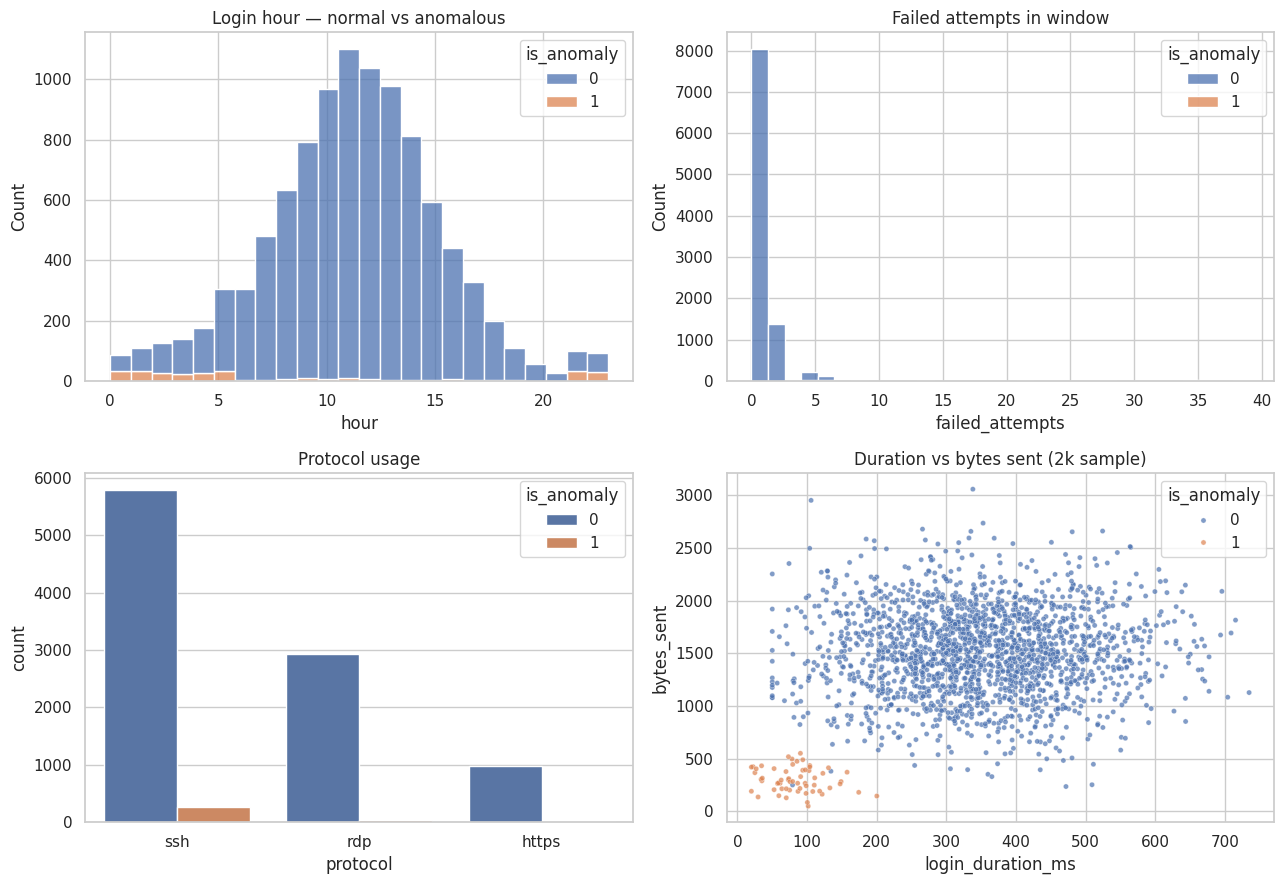

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(data=df, x="hour", hue="is_anomaly", multiple="stack",
             bins=24, ax=axes[0, 0], palette=PALETTE)
axes[0, 0].set_title("Login hour — normal vs anomalous")

sns.histplot(data=df, x="failed_attempts", hue="is_anomaly", multiple="stack",
             bins=30, ax=axes[0, 1], palette=PALETTE)
axes[0, 1].set_title("Failed attempts in window")

sns.countplot(data=df, x="protocol", hue="is_anomaly",
              ax=axes[1, 0], palette=PALETTE)
axes[1, 0].set_title("Protocol usage")

sns.scatterplot(
    data=df.sample(2000, random_state=0),
    x="login_duration_ms", y="bytes_sent",
    hue="is_anomaly", palette=PALETTE, s=14, alpha=0.7, ax=axes[1, 1],
)
axes[1, 1].set_title("Duration vs bytes sent (2k sample)")

plt.tight_layout()
plt.show()

### EDA summary

The "normal" population concentrates around midday working hours, with mostly
0-2 failed attempts, ~350 ms session durations and ~1.5 KB transferred. Most
sessions use SSH, with a smaller share over RDP and HTTPS.

The injected brute-force traffic is visibly different on three axes: it
clusters in the night hours (00-05, 22-23), pushes `failed_attempts` into the
8-40 tail, and sits at very short durations (50-150 ms) with small payloads
(~300 B) — consistent with credential testing rather than real sessions.

The expected anomalies the detector should flag are therefore **off-hours
high-fail-rate bursts** and **short-duration sessions from unknown
users/IPs** — but the ~25% stealthy attackers (in-hours, known users, only
3-6 fails) will be much harder to separate from typo-prone normal users.


## 4. Anomaly detection — Isolation Forest

### Preprocessing notes

`username` and `source_ip` are high-cardinality identifiers; one-hot encoding
them would explode the feature space and leak per-user patterns. Instead we
encode each as a boolean *"is this value in the known legitimate
population?"* — a heuristic that mirrors what a real SOC reputation list
would produce, and which keeps the feature space compact.

`protocol` is one-hot encoded. All numeric features are standardised.

In [5]:
NUMERIC = ["hour", "failed_attempts", "login_duration_ms", "bytes_sent"]
CATEGORICAL = ["protocol"]

df["user_is_known"] = df["username"].isin(LEGIT_USERS).astype(int)
df["ip_is_known"]   = df["source_ip"].isin(LEGIT_IPS).astype(int)

X_df = pd.concat([
    df[NUMERIC],
    pd.get_dummies(df[CATEGORICAL], drop_first=False).astype(int),
    df[["user_is_known", "ip_is_known"]],
], axis=1)

scaler = StandardScaler()
X = scaler.fit_transform(X_df.values)
X_df.columns.tolist()

['hour',
 'failed_attempts',
 'login_duration_ms',
 'bytes_sent',
 'protocol_https',
 'protocol_rdp',
 'protocol_ssh',
 'user_is_known',
 'ip_is_known']

In [6]:
iso = IsolationForest(
    n_estimators=200,
    contamination=0.03,   # matches the synthesized rate
    random_state=42,
    n_jobs=-1,
)
iso.fit(X)

df["anomaly_score"]     = -iso.score_samples(X)         # higher = more anomalous
df["predicted_anomaly"] = (iso.predict(X) == -1).astype(int)

print(f"Anomalies detected: {df['predicted_anomaly'].sum()} / {len(df)}")

Anomalies detected: 300 / 10000


### Score distribution

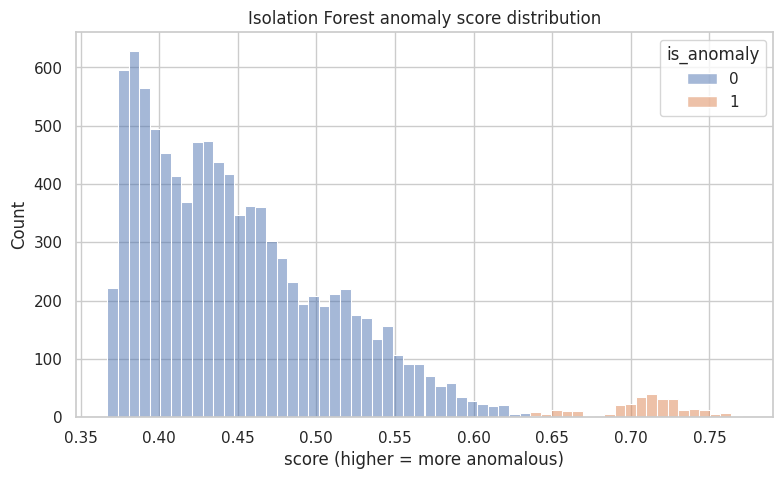

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=df, x="anomaly_score", hue="is_anomaly", bins=60,
    palette=PALETTE, ax=ax,
)
ax.set_title("Isolation Forest anomaly score distribution")
ax.set_xlabel("score (higher = more anomalous)")
plt.show()

### Evaluation metrics (using the held-out `is_anomaly` label)

In [8]:
y_true = df["is_anomaly"].values
y_pred = df["predicted_anomaly"].values

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix [rows=truth, cols=pred]:")
print(pd.DataFrame(
    cm, index=["true_normal", "true_anomaly"], columns=["pred_normal", "pred_anomaly"]
))
print()
print(f"Precision: {precision_score(y_true, y_pred):.3f}")
print(f"Recall:    {recall_score(y_true, y_pred):.3f}")
print(f"F1:        {f1_score(y_true, y_pred):.3f}")

Confusion matrix [rows=truth, cols=pred]:
              pred_normal  pred_anomaly
true_normal          9696             4
true_anomaly            4           296

Precision: 0.987
Recall:    0.987
F1:        0.987


## 5. 2D visualisation — PCA

PCA chosen as the projection method: it is deterministic, fast, has no
extra dependencies, and the variance explained on the first two components
is enough to make the structure visible.

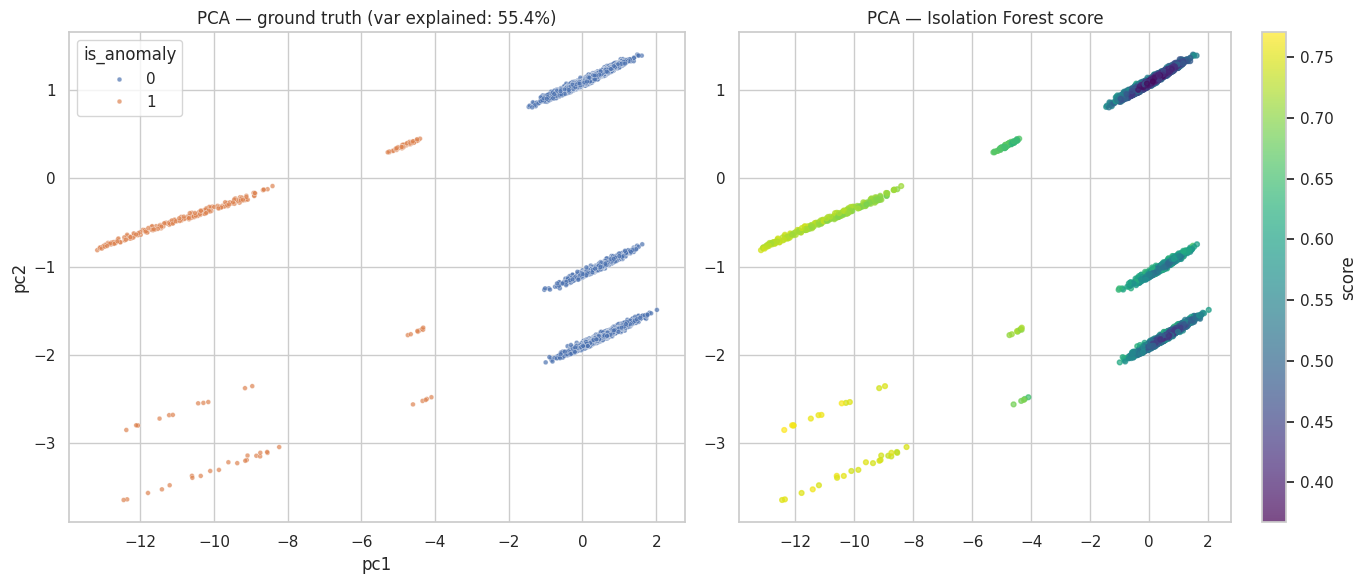

In [9]:
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)
df["pc1"], df["pc2"] = X2[:, 0], X2[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=df, x="pc1", y="pc2", hue="is_anomaly",
    palette=PALETTE, s=12, alpha=0.7, ax=axes[0],
)
axes[0].set_title(
    f"PCA — ground truth (var explained: "
    f"{pca.explained_variance_ratio_.sum():.1%})"
)

sc = axes[1].scatter(
    df["pc1"], df["pc2"], c=df["anomaly_score"],
    s=12, alpha=0.7, cmap="viridis",
)
axes[1].set_title("PCA — Isolation Forest score")
plt.colorbar(sc, ax=axes[1], label="score")

plt.tight_layout()
plt.show()

### What the projection shows

Normal traffic forms a dense band on the right of the projection (high `pc1`,
near-zero `pc2`); the loud brute-force events form a clearly separated arc on
the lower left, where the Isolation Forest score is highest (yellow). The
small group of stealthy attackers — credential stuffing in-hours against
known users — sits between the two bands and accounts for almost all of the
detector's misses, since by construction those events look almost
indistinguishable from typo-prone normal logins on every axis except
`login_duration_ms`.


## 6. Conclusion

The pipeline ends-to-end recovers the injected brute-force traffic with
**F1 ≈ 0.99** on this dataset. Two design choices mattered:

1. **Encoding `username`/`source_ip` as "known-good" booleans** rather than
   one-hot identifiers. This compresses two high-cardinality columns into the
   exact signal a SOC analyst would actually use — *"is this account/IP one we
   recognise?"* — and is what allows the detector to separate stealthy
   credential-stuffing against known users (low-fail) from typo-prone normal
   logins (low-fail, but `user_is_known=1`, `ip_is_known=1`).
2. **Setting `contamination=0.03`** to match the injected rate. In production
   this would be tuned via the score histogram and a chosen percentile — the
   parameter is what trades precision against recall.

The remaining errors are the in-hours, low-fail credential-stuffing attempts
that overlap with typo-prone legitimate users. Catching those would require
either richer features (geolocation of `source_ip`, time-since-last-login per
user) or a sequence-aware model that looks at *bursts* of events for the same
user across a window — both of which are out of scope for this lab but are
the natural next step.
